In [110]:
# importing required libraries
import pandas as pd
import numpy as np

In [111]:
from google.colab import files

In [112]:
uploaded = files.upload()

Saving customers_data.csv to customers_data (1).csv


In [113]:
df = pd.read_csv("customers_data.csv")
print("Initial shape:", df.shape)
df

Initial shape: (15266, 13)


,Unnamed: 0,customer_id,customer_name,gender,city,state,state_code,zip_code,country,continent,dob,customer_age,age_group
0,0,301,Lilly Harding,Female,Wandearah East,South Australia,SA,5523.0,Australia,Australia,1939-03-07,87,Senior citizen
1,1,325,Madison Hull,Female,Mount Budd,Western Australia,WA,6522.0,Australia,Australia,1979-09-27,46,40s
2,2,554,Claire Ferres,Female,Winjallok,Victoria,VIC,3380.0,Australia,Australia,1947-05-26,79,Senior citizen
3,3,786,Jai Poltpalingada,Male,Middle River,South Australia,SA,5223.0,Australia,Australia,1957-09-17,68,60s
4,4,1042,Aidan Pankhurst,Male,Tawonga South,Victoria,VIC,3698.0,Australia,Australia,1965-11-19,60,60s
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15261,15261,2099600,Denisa Dušková,Female,Houston,Texas,TX,77017.0,United States,North America,1936-03-25,90,Senior citizen
15262,15262,2099618,Justin Solórzano,Male,Mclean,Virginia,VA,22101.0,United States,North America,1992-02-16,34,30s
15263,15263,2099758,Svend Petrussen,Male,Wilmington,North Carolina,NC,28405.0,United States,North America,1937-09-11,88,Senior citizen
15264,15264,2099862,Lorenza Rush,Female,Riverside,California,CA,92501.0,United States,North America,1937-12-10,88,Senior citizen


In [114]:
df.describe()

,Unnamed: 0,customer_id,zip_code,customer_age
count,15266.00000,1.526600e+04,15266.000000,15266.000000
mean,7632.50000,1.060508e+06,45349.111359,57.292873
std,4407.05894,6.127097e+05,27169.533072,19.326345
min,0.00000,3.010000e+02,10.000000,23.000000
25%,3816.25000,5.140335e+05,27407.000000,41.000000
50%,7632.50000,1.079244e+06,44120.000000,57.000000
75%,11448.75000,1.593980e+06,62701.000000,74.000000
max,15265.00000,2.099937e+06,99986.000000,91.000000


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15266 entries, 0 to 15265
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     15266 non-null  int64  
 1   customer_id    15266 non-null  int64  
 2   customer_name  15266 non-null  object 
 3   gender         15266 non-null  object 
 4   city           15266 non-null  object 
 5   state          15266 non-null  object 
 6   state_code     15266 non-null  object 
 7   zip_code       15266 non-null  float64
 8   country        15266 non-null  object 
 9   continent      15266 non-null  object 
 10  dob            15266 non-null  object 
 11  customer_age   15266 non-null  int64  
 12  age_group      15266 non-null  object 
dtypes: float64(1), int64(3), object(9)
memory usage: 1.5+ MB


In [116]:
df.head()

,Unnamed: 0,customer_id,customer_name,gender,city,state,state_code,zip_code,country,continent,dob,customer_age,age_group
0,0,301,Lilly Harding,Female,Wandearah East,South Australia,SA,5523.0,Australia,Australia,1939-03-07,87,Senior citizen
1,1,325,Madison Hull,Female,Mount Budd,Western Australia,WA,6522.0,Australia,Australia,1979-09-27,46,40s
2,2,554,Claire Ferres,Female,Winjallok,Victoria,VIC,3380.0,Australia,Australia,1947-05-26,79,Senior citizen
3,3,786,Jai Poltpalingada,Male,Middle River,South Australia,SA,5223.0,Australia,Australia,1957-09-17,68,60s
4,4,1042,Aidan Pankhurst,Male,Tawonga South,Victoria,VIC,3698.0,Australia,Australia,1965-11-19,60,60s


In [117]:
df.tail()

,Unnamed: 0,customer_id,customer_name,gender,city,state,state_code,zip_code,country,continent,dob,customer_age,age_group
15261,15261,2099600,Denisa Dušková,Female,Houston,Texas,TX,77017.0,United States,North America,1936-03-25,90,Senior citizen
15262,15262,2099618,Justin Solórzano,Male,Mclean,Virginia,VA,22101.0,United States,North America,1992-02-16,34,30s
15263,15263,2099758,Svend Petrussen,Male,Wilmington,North Carolina,NC,28405.0,United States,North America,1937-09-11,88,Senior citizen
15264,15264,2099862,Lorenza Rush,Female,Riverside,California,CA,92501.0,United States,North America,1937-12-10,88,Senior citizen
15265,15265,2099937,Zygmunt Kaminski,Male,Bloomfield Township,Michigan,MI,48302.0,United States,North America,1965-08-18,60,60s


In [118]:
df.dtypes

,0
Unnamed: 0,int64
customer_id,int64
customer_name,object
gender,object
city,object
state,object
state_code,object
zip_code,float64
country,object
continent,object


In [119]:
df.isnull().sum()

,0
Unnamed: 0,0
customer_id,0
customer_name,0
gender,0
city,0
state,0
state_code,0
zip_code,0
country,0
continent,0


In [120]:
df.columns = (
    df.columns.str.replace(" ", "_")
    .str.lower()
    .str.strip()
)

In [121]:
df["state_code"] = df["state_code"].astype("str").str.strip().str.upper()
df["state_code"] = df["state_code"].replace(["NAN", "NONE", ""], np.nan).fillna("UNKNOWN")

In [122]:

# Drop stray index column if exist
df.drop(columns=["unnamed:_0"], inplace=True)

# Renaming
df.rename(columns={"customerid": "customer_id"}, inplace=True)



In [123]:
df

,customer_id,customer_name,gender,city,state,state_code,zip_code,country,continent,dob,customer_age,age_group
0,301,Lilly Harding,Female,Wandearah East,South Australia,SA,5523.0,Australia,Australia,1939-03-07,87,Senior citizen
1,325,Madison Hull,Female,Mount Budd,Western Australia,WA,6522.0,Australia,Australia,1979-09-27,46,40s
2,554,Claire Ferres,Female,Winjallok,Victoria,VIC,3380.0,Australia,Australia,1947-05-26,79,Senior citizen
3,786,Jai Poltpalingada,Male,Middle River,South Australia,SA,5223.0,Australia,Australia,1957-09-17,68,60s
4,1042,Aidan Pankhurst,Male,Tawonga South,Victoria,VIC,3698.0,Australia,Australia,1965-11-19,60,60s
...,...,...,...,...,...,...,...,...,...,...,...,...
15261,2099600,Denisa Dušková,Female,Houston,Texas,TX,77017.0,United States,North America,1936-03-25,90,Senior citizen
15262,2099618,Justin Solórzano,Male,Mclean,Virginia,VA,22101.0,United States,North America,1992-02-16,34,30s
15263,2099758,Svend Petrussen,Male,Wilmington,North Carolina,NC,28405.0,United States,North America,1937-09-11,88,Senior citizen
15264,2099862,Lorenza Rush,Female,Riverside,California,CA,92501.0,United States,North America,1937-12-10,88,Senior citizen


In [124]:
text_cols = ["gender", "city", "state", "country", "continent"]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype("str").str.strip().str.title()
        df[col] = df[col].replace(["Nan", "None", ""], np.nan)
        df[col] = df[col].fillna("Unknown")

In [125]:
#  INITIAL MISSING VALUE / DUPLICATE OVERVIEW

missing = df.isnull().mean() * 100
print("\nMissing % by column (before cleaning):")
print(missing[missing > 0].sort_values(ascending=False))

dup_count = df.duplicated().sum()
print(f"\nFull-row duplicates found: {dup_count}")
df = df.drop_duplicates()




Missing % by column (before cleaning):
Series([], dtype: float64)

Full-row duplicates found: 0


In [126]:
df["customer_name"] = df["customer_name"].astype("str").str.strip()

In [127]:
# HANDLE MISSING VALUES
df["zip_code"] = df["zip_code"].astype("str").str.strip()
df["zip_code"] = df["zip_code"].replace(["nan", "None", ""], np.nan)
df["zip_code"] = df["zip_code"].fillna("Unknown")

In [128]:
# DATA TYPE CONVERSIONS

df["dob"] = pd.to_datetime(df["dob"], errors="coerce")

df["customer_age"] = pd.to_numeric(df["customer_age"], errors="coerce").astype("Int64")

# Category dtype AFTER cleaning strings, so categories are consistent
cat_cols = ["gender", "city", "state", "state_code", "country", "continent", "age_group"]
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

print("\nFinal dtypes:")
print(df.dtypes)


Final dtypes:
customer_id               int64
customer_name            object
gender                 category
city                   category
state                  category
state_code             category
zip_code                 object
country                category
continent              category
dob              datetime64[ns]
customer_age              Int64
age_group              category
dtype: object


In [129]:
df.dtypes

,0
customer_id,int64
customer_name,object
gender,category
city,category
state,category
state_code,category
zip_code,object
country,category
continent,category
dob,datetime64[ns]


# EDA

In [130]:
# Gender distribution
print(df["gender"].value_counts())

gender
Male      7748
Female    7518
Name: count, dtype: int64


In [131]:
# Gender percentage
(df["gender"].value_counts(normalize=True) * 100).round(2)

,proportion
gender,
Male,50.75
Female,49.25


In [132]:
# Country-wise customers
df["country"].value_counts()

,count
country,
United States,6828
United Kingdom,1944
Canada,1553
Germany,1473
Australia,1420
Netherlands,733
France,670
Italy,645


In [133]:
# Top 10 cities
df["city"].value_counts().head(10)

,count
city,
Toronto,204
New York,130
Los Angeles,119
Montreal,97
Chicago,92
Houston,86
Calgary,70
Dallas,68
Philadelphia,62


In [134]:
# Average age by gender
df.groupby("gender", observed=True)["customer_age"].mean()

,customer_age
gender,
Female,57.392791
Male,57.195922


In [135]:
# Top 10 states
df["state"].value_counts().head(10)

,count
state,
California,715
Ontario,644
Texas,522
New South Wales,430
New York,423
Freistaat Bayern,420
Illinois,368
Florida,348
Queensland,297


In [136]:
# Age group vs gender crosstab
pd.crosstab(df["age_group"], df["gender"])

gender,Female,Male
age_group,,
20s,640,671
30s,1072,1186
40s,1167,1134
50s,1085,1142
60s,1166,1164
Senior citizen,2388,2451


In [137]:
# Continent-wise customer count
df.groupby("continent", observed=True)["customer_id"].count().sort_values(ascending=False)

,customer_id
continent,
North America,8381
Europe,5465
Australia,1420


# **Visualizations**

In [138]:
import matplotlib.pyplot as plt

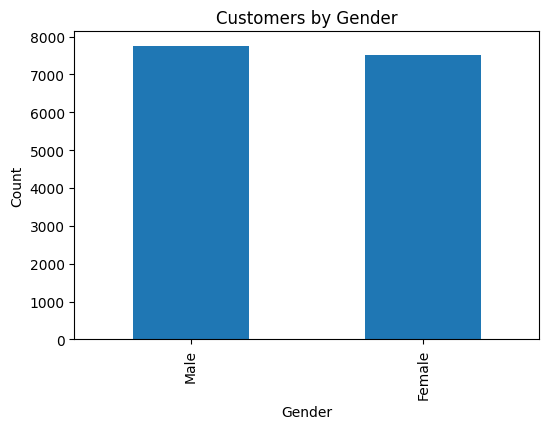

In [139]:
# Customers by Gender
df["gender"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Customers by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

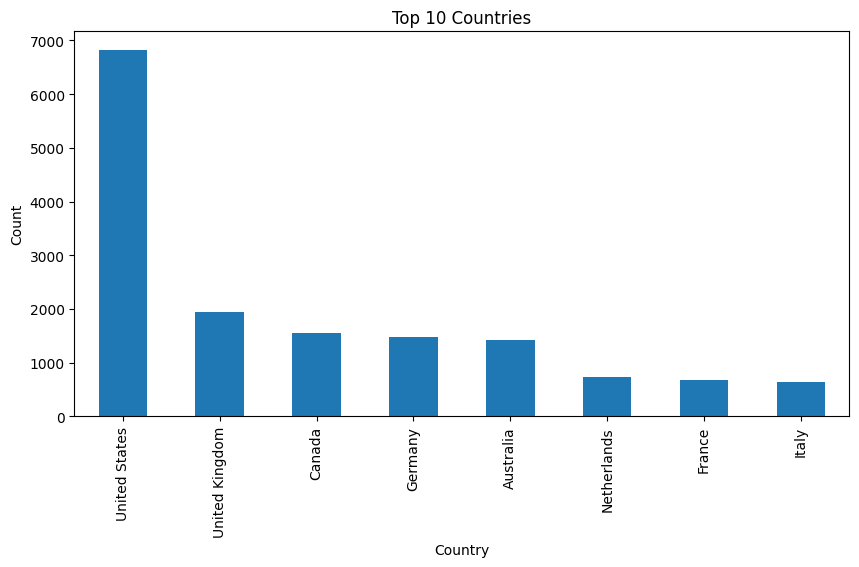

In [140]:
# Top 10 Countries
df["country"].value_counts().head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()


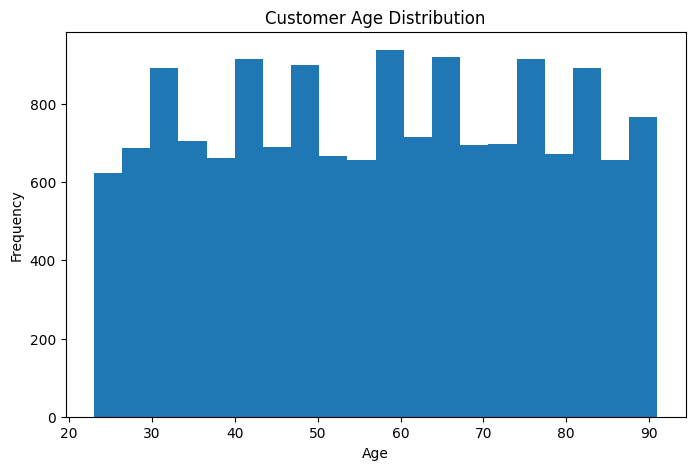

In [141]:
# Customer Age Distribution
plt.figure(figsize=(8,5))
plt.hist(df["customer_age"], bins=20)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

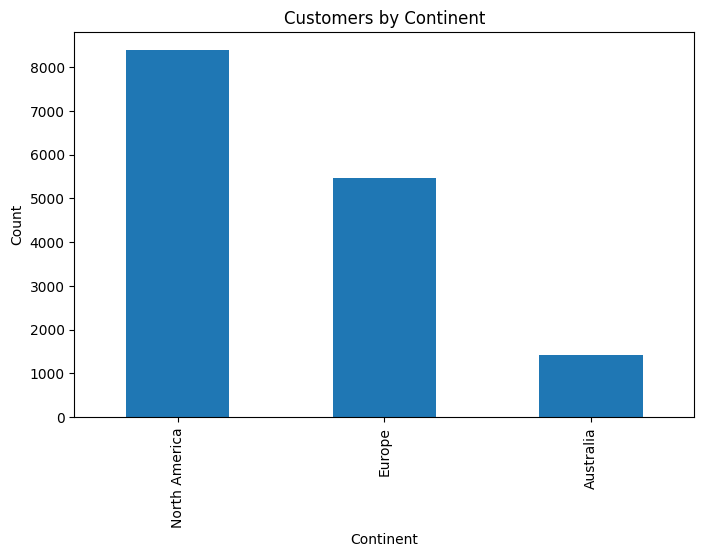

In [142]:
# Customers by Continent
df["continent"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Customers by Continent")
plt.xlabel("Continent")
plt.ylabel("Count")
plt.show()

In [143]:
# Final QA check before export
print("Remaining nulls:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nRemaining duplicates:", df.duplicated().sum())
print("\nFinal shape:", df.shape)

df.to_csv("customers_py.csv", index=False)
files.download("customers_py.csv")
print("\nSaved: customers_py.csv")

Remaining nulls:
 Series([], dtype: int64)

Remaining duplicates: 0

Final shape: (15266, 12)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Saved: customers_py.csv
